In [28]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.table import Table
from matplotlib.patches import Ellipse
from matplotlib.patches import Circle
import os
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import numpy as np
import lenstool
from lenstool.potentials import sis
lenstool.__version__

'8.10.1'

In [218]:
ra = np.array([180.1711571,180.1706384, 180.1670402,180.1669367,180.1649901, 180.1647511,180.1620085,180.1585672,180.1578159,180.1571312,180.1547416]) 
dec = np.array([-1.448282774,-1.45269478, -1.452993158,-1.451199272,-1.449266441, -1.460621377,-1.446011697,-1.447444124,-1.451612291,-1.452994629,-1.446817617]) 

ra_med = np.median(ra)
dec_med = np.median(dec)

# find galaxy closest to median
dist = np.sqrt((ra - ra_med)**2 + (dec - dec_med)**2)
central_idx = np.argmin(dist)

# shift coordinates so THAT galaxy is at (0,0)
ra0 = ra[central_idx]
dec0 = dec[central_idx]

x_arcsec = (ra - ra0) * 3600 * np.cos(np.deg2rad(dec0))
y_arcsec = (dec - dec0) * 3600


lt = lenstool.Lenstool()

for i, (xi, yi) in enumerate(zip(x_arcsec, y_arcsec)):

    if i == central_idx:
        sigma = 900   
    else:
        sigma = 200  

    lt.add_lens(sis(xi, yi, 0.27, sigma))


lt.set_cosmology(73.5, 0.3, 0.7, -1)
lt.set_field(41)
lt.set_grid(2000, 1)
lt.get_lenses()

type,n,x,y,z
int64,str1,float64,float64,float64
1,1,22.194098100700547,3.541201200000277,0.27
1,1,20.327375434156643,-12.342020400000209,0.27
1,1,7.377999110786642,-13.416181199999766,0.27
1,1,7.0055183011046545,-6.958191599999886,0.27
1,1,0.0,0.0,0.27
1,1,-0.8601247683756806,-40.877769600000136,0.27
1,1,-10.7303263981291,11.717078399999714,0.27
1,1,-23.115043407156982,6.560341200000064,0.27
1,1,-25.818858212233312,-8.445059999999938,0.27


In [227]:
tab = Table(names=['n','x','y','a','b','theta','z','mag'], dtype=['str',*['float',]*7]) #n is ID
tab.add_row(['Source 1', 5, 0, 1, 1, 0, 1.4, 20]) #a & b are semi-major axes. If a=b, circle. 
tab.meta['iref'], tab.meta['ref_ra'], tab.meta['ref_dec'] = 3, 0, 0
lt.set_sources(tab)
lt.get_sources()

n,x,y,a,b,theta,z,mag
str8,float64,float64,float64,float64,float64,float64,float64
Source 1,5.0,0.0,1.0,1.0,0.0,1.4,20.0


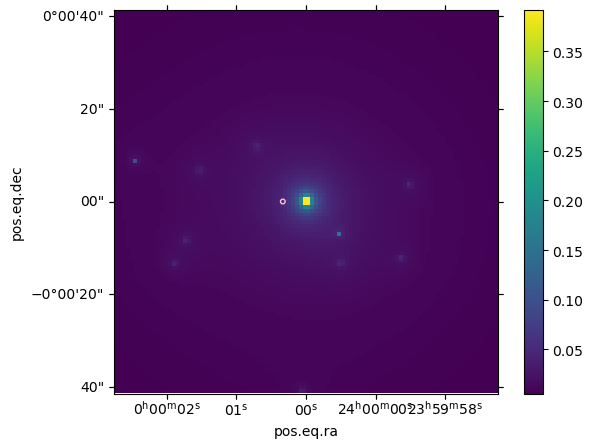

In [228]:
mass, wcs = lt.g_mass(3, 100, 0.27, 1.4) #(mass quantity/type, resolution/grid size, lens z, source z)

fig = plt.figure()
ax = fig.add_axes([0.15, 0.1, 0.8, 0.8], projection=wcs) #Numbers are for graph pos
plt.imshow(mass)
plt.colorbar()

for row in lt.get_sources(): 
    ellipse = Ellipse((row['x']/3600.,row['y']/3600.), #conversion from arcsecs to degrees
                      width=row['b']/3600, 
                      height=row['a']/3600,
                      edgecolor='pink',
                      facecolor='none',
                      angle =row['theta']+90,
                      transform=plt.gca().get_transform('world')
                     )
 
    ax.add_patch(ellipse)

In [229]:
lt.e_lensing()
lt.get_images()

n,x,y,a,b,theta,z,mag
str8,float64,float64,float64,float64,float64,float64,float64
Source 1,28.195666652928793,9.25429797263986,1.114943436084857,1.000000000117055,133.58938550717087,1.4,19.88186791217332
Source 1,-12.797008580558789,-2.072626113255502,1.0247000814916798,1.0000000000061788,99.1146231975825,1.4,19.973508073131253


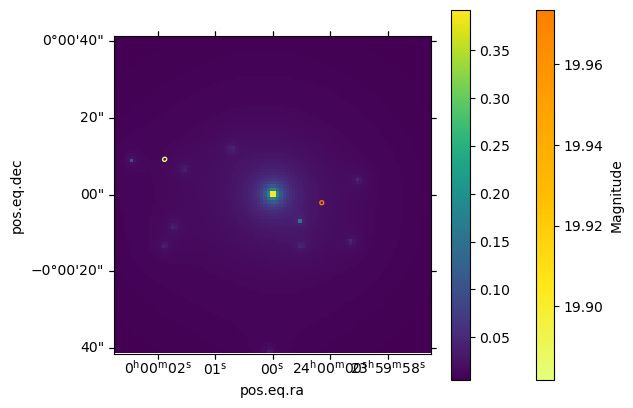

In [230]:
def plot_images():
    fig = plt.figure()
    ax = fig.add_subplot(projection=wcs)
    plt.imshow(mass)

    norm = Normalize(min(lt.get_images()['mag']), max(lt.get_images()['mag']))
    for row in lt.get_images(): 
        ellipse = Ellipse((row['x']/3600.,row['y']/3600.),
                          width=row['b']/3600,
                          height=row['a']/3600,
                          facecolor = 'none',
                          angle =row['theta'] + 90,
                          transform=plt.gca().get_transform('world')
                         )
         # Assign color to the ellipse based on the magnification

        color = cm.ScalarMappable(norm=norm, cmap = 'Wistia').to_rgba(row['mag'])
        ellipse.set_edgecolor(color)

        ax.add_patch(ellipse)

    # Creating a ScalarMappable object for colorbar
    cmap = cm.ScalarMappable(norm=norm, cmap = 'Wistia')
    cmap.set_array(tab['mag'])

    # Adding the colorbar
    colorbar = plt.colorbar(cmap, ax=ax)
    colorbar.set_label('Magnitude')
    plt.colorbar()
    plt.show()
plot_images()